In [1]:
%matplotlib inline
import sys
import os
import time
import numpy as np

import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
import os

notebook_path = os.getcwd()
print(notebook_path)

/scratch/ff2183/Causality-Simple-Models/L96-Stochastic/L96_Stochastic_Fj/Energy_conserving/Sequential/Local_Standardization/Discrete/Test_Sharing/Energy_Conserving


In [3]:
# Mean and standard deviations (the neural networks run in a standardized space)
# We will need this to de-standardize the results back into the real space
mean_i = np.load('./results/train_mean_i.npy')
std_i = np.load('./results/train_std_i.npy')

## Loading the model

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from nn import DiscreteEnergyConservingModel
        
# Initialize the model
input_dim = 20  # Dimensionality of the system
hidden_dim = 100  # Number of hidden units (Note: maybe try hidden_dim > input_dim)
output_dim = 20  # Dimensionality of the output
# Choose the same device as used during training (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 1. Define Dummy Tensors to satisfy the constructor
dummy_A = torch.zeros(input_dim, input_dim).to(device)
dummy_F = torch.zeros(input_dim).to(device)

train_mean_i = np.load('./results/train_mean_i.npy')
train_std_i = np.load('./results/train_std_i.npy')
model = DiscreteEnergyConservingModel(M_init=dummy_A, 
                              F_init=dummy_F, 
                              feature_means = train_mean_i, 
                              feature_stds = train_std_i, 
                              N=input_dim, hidden_nodes=hidden_dim, orthogonal_map='exp').to(device)
# 3. Load the saved weights
checkpoint_path = "./results/best_model.pth"
state_dict = torch.load(checkpoint_path, map_location=torch.device('cpu'))
#state_dict = torch.load(checkpoint_path, map_location=device)
model.load_state_dict(state_dict)

# 3. Move model to device and SET TO EVAL MODE
model = model.to(device)
model.eval() # <--- Crucial for inference!

########## Noise covariance matrix
Sigma = np.load('./results/Sigma_matrix_identity.npy')

# Code to compute responses

In [6]:
def run_streamed_ensembles_step_discrete(
    long_trajectory,
    model,
    Sigma,
    N_steps,
    mean_i,
    std_i,
    std_Ft=None,            # standardized forcing, shape (N_steps, dim)
    dt_phys=0.01,           # physical dt scaling for forcing (often 1.0 for discrete maps, adjust as needed)
    N_total=int(1e7),
    N_batch=int(1e4),
    base_seed=12345,
    use_gpu=True,
    dtype=torch.float64,
    verbose=True,
):
    """
    Streamed ensemble runner for DISCRETE MAPS: compares control vs forced ensemble.
    The ONLY perturbation is the time-dependent forcing std_Ft(t)*dt_phys.

    Returns:
        C_mean, C_var, P_mean, P_var
    """

    # Device setup
    device = torch.device('cuda' if (torch.cuda.is_available() and use_gpu) else 'cpu')
    model = model.to(device).eval()

    # Move constants to device
    Sigma_t = torch.tensor(Sigma, dtype=dtype, device=device)
    mean_t  = torch.tensor(mean_i, dtype=dtype, device=device)
    std_t   = torch.tensor(std_i, dtype=dtype, device=device)

    dim = long_trajectory.shape[1]

    # Standardized forcing
    if std_Ft is None:
        raise ValueError("std_Ft must be provided when simulating a time-dependent forcing.")

    std_Ft = np.asarray(std_Ft)
    if std_Ft.ndim == 1:
        std_Ft = np.tile(std_Ft[:, None], (1, dim))

    if std_Ft.shape != (N_steps, dim):
        raise ValueError(f"std_Ft must have shape (N_steps, dim), got {std_Ft.shape}")

    std_Ft_t = torch.tensor(std_Ft, dtype=dtype, device=device)

    # Global accumulators
    C_mean_global = C_var_global = None
    P_mean_global = P_var_global = None

    N_done = 0
    batch_index = 0
    rng_global = np.random.default_rng(base_seed)

    while N_done < N_total:

        # Ensemble size for this batch
        Nens = int(min(N_batch, N_total - N_done))

        # Sample initial conditions
        idx = rng_global.integers(0, len(long_trajectory), size=Nens)
        x0 = long_trajectory[idx]

        # Control and Forced ensembles start equal
        x_ctl = torch.tensor(x0, dtype=dtype, device=device)
        x_prt = torch.tensor(x0, dtype=dtype, device=device)

        # Batch accumulators
        C_mean_batch = np.zeros((N_steps, dim))
        C_var_batch  = np.zeros((N_steps, dim))
        P_mean_batch = np.zeros((N_steps, dim))
        P_var_batch  = np.zeros((N_steps, dim))

        # Paired noise generator
        gen = torch.Generator(device=device)
        gen.manual_seed(base_seed + batch_index)

        with torch.no_grad():
            for t in range(N_steps):

                # 1. Record stats at current time step t
                ctl_destd = mean_t + x_ctl * std_t
                prt_destd = mean_t + x_prt * std_t

                C_mean_batch[t] = ctl_destd.mean(0).cpu().numpy()
                C_var_batch[t]  = ctl_destd.var(0).cpu().numpy()

                P_mean_batch[t] = prt_destd.mean(0).cpu().numpy()
                P_var_batch[t]  = prt_destd.var(0).cpu().numpy()

                # 2. Get deterministic NEXT STATE from discrete model
                # Note: Unlike the continuous case (dx), this outputs x_{t+1} directly
                next_ctl_det = model(x_ctl)
                next_prt_det = model(x_prt)

                # 3. Generate paired Wiener noise
                w = torch.randn((Nens, dim), dtype=dtype, device=device, generator=gen)
                noise = w @ Sigma_t.T

                # 4. Update control ensemble
                x_ctl = next_ctl_det + noise

                # 5. Update forced ensemble
                # We add the forcing directly to the state prediction
                Ft = std_Ft_t[t] * dt_phys
                Ft_batch = Ft.unsqueeze(0).expand(Nens, -1)
                x_prt = next_prt_det + Ft_batch + noise  # SAME NOISE ensures clean response

        # ------ Merge batch into global (Chan merging) ------
        if C_mean_global is None:
            C_mean_global = C_mean_batch.copy()
            C_var_global  = C_var_batch.copy()
            P_mean_global = P_mean_batch.copy()
            P_var_global  = P_var_batch.copy()
        else:
            n1 = N_done
            n2 = Nens

            # Control
            dm = C_mean_batch - C_mean_global
            C_mean_global += dm * (n2 / (n1 + n2))
            C_var_global = (
                (n1 * C_var_global + n2 * C_var_batch +
                 (n1 * n2 / (n1 + n2)) * (dm ** 2)) / (n1 + n2)
            )

            # Perturbed
            dm_p = P_mean_batch - P_mean_global
            P_mean_global += dm_p * (n2 / (n1 + n2))
            P_var_global = (
                (n1 * P_var_global + n2 * P_var_batch +
                 (n1 * n2 / (n1 + n2)) * (dm_p ** 2)) / (n1 + n2)
            )

        N_done += Nens
        batch_index += 1
        if verbose:
            print(f"Batch {batch_index}: {N_done}/{N_total} members")

    return C_mean_global, C_var_global, P_mean_global, P_var_global

# Response functions to step

## Define step forcing

In [7]:
# Load the long trajectory, but keep only the first 10^7 points
long_trajectory = np.load('./results/x_t_emulated.npy')#[0:10**4]
long_trajectory_std = (long_trajectory-mean_i)/std_i

sigmaS = np.std(long_trajectory,0)

In [9]:
# example parameters (adapt to your environment)
period_long = 100
N_total = 10**6
N_batch = 10**5   # choose to fit GPU/CPU memory
base_seed = 12345
K = 20

# Parameters for the forcing
mu = 10
width = 3
sigma_10 = 10*sigmaS[10]


### Define the forcing
# Step forcing of x_j is defined as sigma_j
# In the numerics the force is defined as F per time step (dt), with dt = 0.01
dt = 0.01
t_array = np.linspace(dt, period_long*dt, period_long)
# 1. Calculate periodic distance from the peak (mu)
k_indices = np.arange(K)
dist = np.minimum(np.abs(k_indices - mu), K - np.abs(k_indices - mu))

# 2. Build the Gaussian perturbation vector (Spatial profile)
delta_F = sigma_10 * np.exp(-0.5 * (dist / width)**2)

# 3. Initialize the forcing array (Time x Space)
# Changing the second dimension from 6 to K to cover the whole L96 domain
forcing = np.zeros([period_long, K])
# 4. Apply the spatial forcing across all time steps
# You can use a loop like your previous code:
for t in range(period_long):
    forcing[t, :] = delta_F

# Standardize the forcing term
std_f = forcing/std_i

C_mean, C_var, P_mean, P_var = run_streamed_ensembles_step_discrete(
        long_trajectory_std,
        model,
        Sigma,
        period_long,
        mean_i,
        std_i,
        std_Ft=std_f,            # standardized forcing, shape (N_steps, dim)
        dt_phys=0.01,           # physical dt scaling for forcing (often 1.0 for discrete maps, adjust as needed)
        N_total=N_total,
        N_batch=N_batch,
        base_seed=12345,
        use_gpu=True,
        dtype=torch.float32,
        verbose=True,
        )

R_mean = (P_mean-C_mean)
R_var = (P_var-C_var)

# Save the control and perturbed ensemble
np.save('./results_responses_Gaussian/response_mean_x_10.npy',R_mean)
np.save('./results_responses_Gaussian/response_var_x_10.npy',R_var)

Batch 1: 10000/10000 members


In [10]:
R_mean = np.load('./results_responses_Gaussian/response_mean_x_10.npy')
R_var = np.load('./results_responses_Gaussian/response_var_x_10.npy')

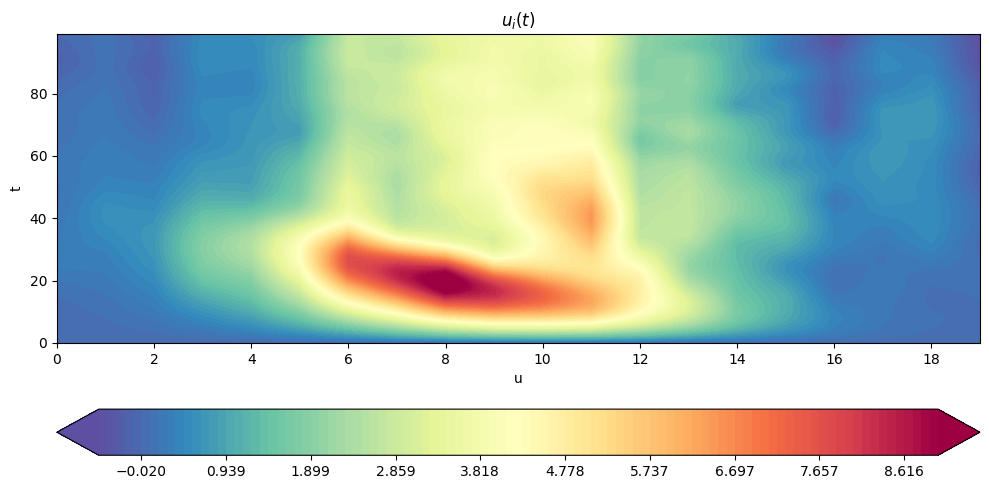

In [12]:
from matplotlib import colormaps
from matplotlib.ticker import MaxNLocator 

fig = plt.figure(figsize=(10, 5))

# 1. Define the EXACT levels you want to plot
# This forces Matplotlib to only draw contours within this specific range
fixed_levels = np.linspace(-0.5, 9.0, 100)

ax = fig.add_subplot(1, 1, 1)
# Apply the exact same strict boundaries to the second plot
plt.contourf(R_mean[0:200], levels=fixed_levels, vmin=-0.5, vmax=9, cmap='Spectral_r', extend='both')
plt.colorbar(orientation="horizontal")
plt.xlabel("u")
plt.ylabel("t")
plt.title("$u_i(t)$")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout() # Just to make sure the horizontal colorbars don't overlap with x-labels!
plt.show()

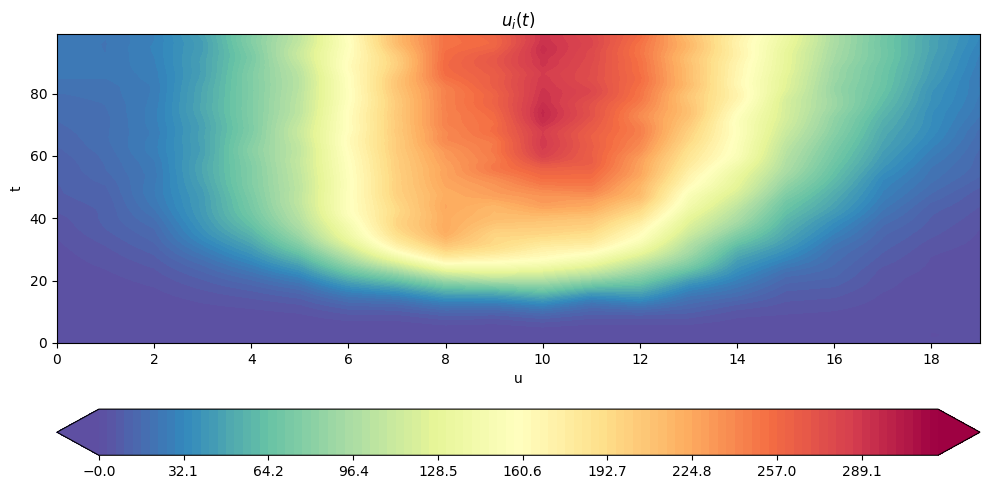

In [13]:
from matplotlib import colormaps
from matplotlib.ticker import MaxNLocator 

fig = plt.figure(figsize=(10, 5))

# 1. Define the EXACT levels you want to plot
# This forces Matplotlib to only draw contours within this specific range
fixed_levels = np.linspace(-0.002, 318.0, 100)

ax = fig.add_subplot(1, 1, 1)
# Apply the exact same strict boundaries to the second plot
plt.contourf(R_var[0:200], levels=fixed_levels, vmin=-0.002, vmax=318.0, cmap='Spectral_r', extend='both')
plt.colorbar(orientation="horizontal")
plt.xlabel("u")
plt.ylabel("t")
plt.title("$u_i(t)$")
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

plt.tight_layout() # Just to make sure the horizontal colorbars don't overlap with x-labels!
plt.show()